In [1]:
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import cm
# Reproducibility
rng = np.random.default_rng(42)
from scipy.signal import stft
import cmath as c


In [12]:
#Parameters
num_samples = 200000
X1 = pd.DataFrame()
X2 = pd.DataFrame()
snr_db = 10
M = 16   # M - QAM
k = int(np.sqrt(M))
block_size = 1000  # samples per fading block; adjust as desired
#block_size = int(num_samples*(1/20))
#assert k * k == M, "M must be a perfect square for square QAM"

levels = np.arange(-(k - 1), k, 2, dtype=float) # gives array of numbers. 4QAM wilsl be [-1,1]

#Bewlow: has both i and q loop through the values in "levels." 
constellation = np.array([i + 1j * q for i in levels for q in levels], dtype=complex)
constellation /= np.sqrt(np.mean(np.abs(constellation) ** 2)) #normalized to unit average power. RMS


# Creating "pure" QAM symbols
label_indices = rng.integers(0, M, size=num_samples) 

y_clean = constellation[label_indices]
y_Unique = np.unique(y_clean)
unique_labels = np.unique(label_indices)

## Noise generation for AWGN
signal_power = np.mean(np.abs(y_clean) ** 2)  # ~= 1 after normalization
noise_power = signal_power / (10 ** (snr_db / 10))
noise = np.sqrt(noise_power / 2) * (
    rng.standard_normal(num_samples) + 1j * rng.standard_normal(num_samples)
)


C:\Users\Jonas Pedesk\AppData\Local\Temp\ipykernel_7968\2544841416.py:126: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap( "tab20",M)


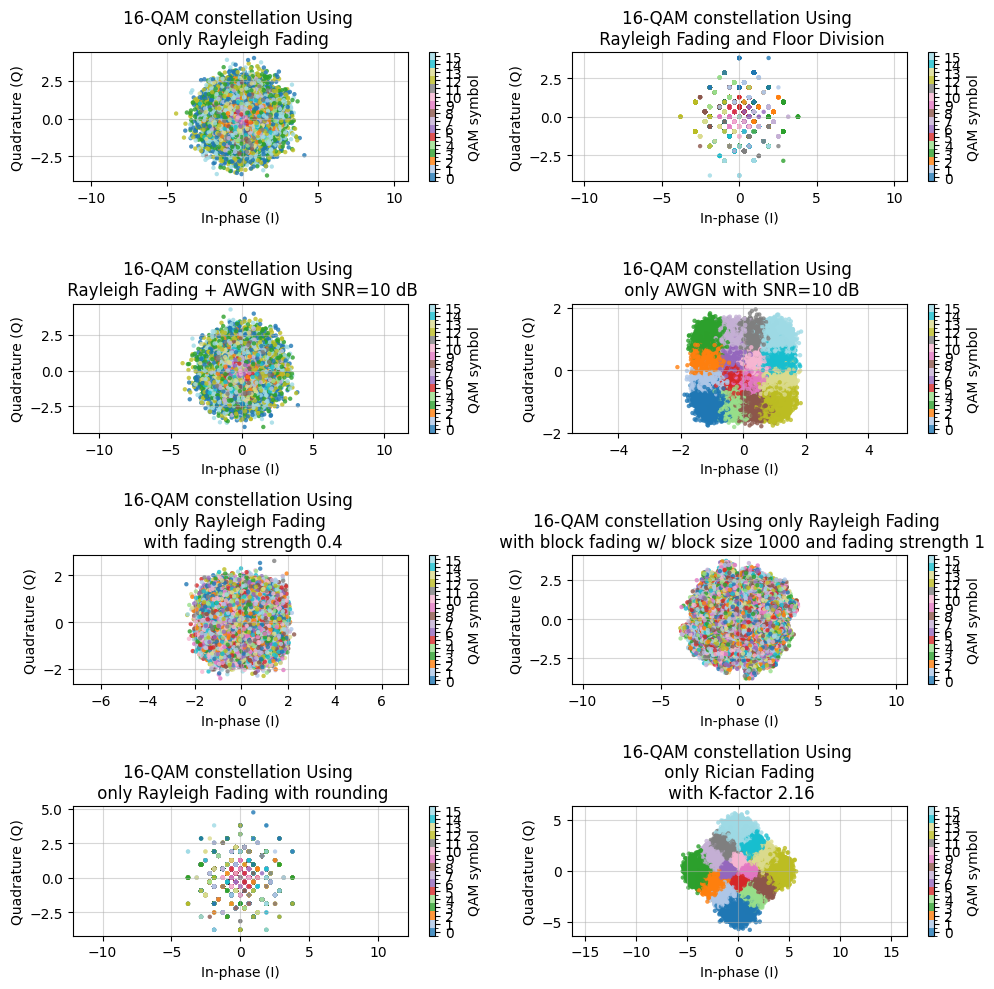

'\n\n\nplt.figure(figsize=(15, 15))\nsc3 = plt.scatter(\n    inPhaseCombined2, quadRatureCombined2,\n    c=label_indices, \n    cmap=cmap, \n    norm=norm,\n    s=10, \n    alpha=0.8, \n    linewidths=5\n)\n\ncbar = plt.colorbar(sc3, ticks=np.arange(M))\ncbar.set_label("QAM symbol")\n\ntick_labels = [f"{z}" for z in unique_labels]\ncbar.set_ticklabels(tick_labels)\n\nplt.title(f"{M}-QAM constellation Using Rayleigh Fading + AWGN with SNR={snr_db} dB")\nplt.xlabel("In-phase (I)")\nplt.ylabel("Quadrature (Q)")\nplt.axis("equal")\nplt.grid(True, alpha=0.5)\nplt.show()\n\nplt.figure(figsize=(15, 15))\nsc4 = plt.scatter(\n    inPhaseAWGN, \n    quadRatureAWGN,\n    c=label_indices, \n    cmap=cmap, \n    norm=norm,\n    s=10, \n    alpha=0.8, \n    linewidths=5\n)\n\ncbar = plt.colorbar(sc4, ticks=np.arange(M))\ncbar.set_label("QAM symbol")\n\ntick_labels = [f"{z}" for z in unique_labels]\ncbar.set_ticklabels(tick_labels)\n\nplt.title(f"{M}-QAM constellation Using only AWGN with SNR={snr_db

In [13]:

# Rayleigh fading channel
realDist = rng.normal(0, 1, num_samples)
realDist = realDist/ np.sqrt(2)
  
imagDist = rng.normal(0, 1, num_samples)
imagDist = imagDist/ np.sqrt(2)
h = (realDist + 1j * imagDist) 
rChannel = y_clean * h
rChannelPD = pd.DataFrame(rChannel)
rChannelColumn = np.column_stack((rChannel.real, rChannel.imag))



#Rayleigh fading channel with floor division

realDistFloor = realDist // np.sqrt(2)
imagDistFloor = imagDist // np.sqrt(2)  
hFloor = (realDistFloor + 1j * imagDistFloor)
rChannelFloor = y_clean * hFloor

#Rayleigh fading with rounding
realDistRound = np.round(realDist)
imagDistRound = np.round(imagDist)
hRound = (realDistRound + 1j * imagDistRound)
rChannelRound = y_clean * hRound


#### Rayleigh fading with adjustable fading strength

rng = np.random.default_rng(42)
# 0.0 = no fading, 1.0 = full Rayleigh fading
fading_strength = 0.4
h_i = rng.normal(0, 1, num_samples)
h_q = rng.normal(0, 1, num_samples)
h_rayleigh = (h_i + 1j * h_q) / np.sqrt(2)
# Blend a static LOS-like component with Rayleigh fading to soften the scatter
h_st = (1 - fading_strength) + fading_strength * h_rayleigh
constellation_points = np.array([-1-1j, -1+1j, +1-1j, +1+1j])
indices = np.array(rng.integers(0, 4, size=num_samples))
constellation_point_samples = constellation_points[indices]
# y = h*x + n
received_samples = h_st * constellation_point_samples
received_inphase = received_samples.real
received_quadrature = received_samples.imag



### Rayleigh with Block Fading
fading_strength_block = 1

num_blocks = int(np.ceil(num_samples / block_size))

# generate one complex fading coefficient per block
h_i_blocks = rng.normal(0, 1, num_blocks)
h_q_blocks = rng.normal(0, 1, num_blocks)
h_rayleigh_blocks = (h_i_blocks + 1j * h_q_blocks) / np.sqrt(2)
h_blocks = (1 - fading_strength_block) + fading_strength_block * h_rayleigh_blocks

# expand to per-sample channel
h_block = np.repeat(h_blocks, block_size)[:num_samples]

# received samples under block fading (no noise)
received_samples_block = h_block * constellation_point_samples
blockChannel = received_samples_block + noise
received_inphase_block = received_samples_block.real
received_quadrature_block = received_samples_block.imag

#rayleighBlockInPhase = received_inphase_block
#rayleighBlockQuadrature = received_quadrature_block
rayleighBlockInPhase = blockChannel.real
rayleighBlockQuadrature = blockChannel.imag


X_noisy = y_clean + noise
X1 = pd.DataFrame(X_noisy)
X2 = pd.concat([X2,X1],axis = 0)
# Optional ML-friendly real-valued features (I, Q)
X = np.column_stack((X_noisy.real, X_noisy.imag))

#Rayleigh fading channel implementation 
R_channel = rChannel + noise
R2 = pd.DataFrame(R_channel)
R3 = np.column_stack((R_channel.real, R_channel.imag))

# Rician Channel fading implementation
K_factor = 2.16  # Rician K-factor (ratio of LOS to scattered power)
h_los = 1  # LOS component (can be complex if desired)
g1 = np.sqrt(K_factor/2*(K_factor+1))
g2 = np.sqrt((1/(2*(K_factor+1))))
h_scatter_i = rng.normal(g1, g2, num_samples)
h_scatter_q = rng.normal(g1, g2, num_samples)
h_scatter = (h_scatter_i + 1j * h_scatter_q)
hChannel = h_scatter * y_clean
RicianChannel = hChannel + noise

h_scatter_iMat = g2*(rng.normal(0, 1, num_samples))+g1
h_scatter_qMat = g2*(rng.normal(0, 1, num_samples))+g1
h_scatterMat = (h_scatter_iMat + 1j * h_scatter_qMat)
hChannelMat = h_scatterMat * y_clean
RicianChannelMat = hChannelMat + noise

inPhaseRayleigh = rChannel.real
quadRatureRayleigh = rChannel.imag

inPhaseRayleighFloor = rChannelFloor.real
quadRatureRayleighFloor = rChannelFloor.imag

inPhaseRayleighRound = rChannelRound.real
quadRatureRayleighRound = rChannelRound.imag

#inPhaseRician = hChannel.real
#quadRatureRician = hChannel.imag
inPhaseRician = RicianChannel.real
quadRatureRician = RicianChannel.imag



inPhaseAWGN = X[:, 0]
quadRatureAWGN = X[:, 1]

inPhaseCombined2 = R3[:, 0]
quadRatureCombined2 = R3[:, 1]

unique_indices = np.searchsorted(y_Unique, y_clean[label_indices])

base = cm.get_cmap( "tab20",M)
cmap = ListedColormap(base(np.arange(M)))
bounds = np.arange(-0.5, M + 0.5, 1)
norm = BoundaryNorm(bounds, ncolors=cmap.N)

fig, axes = plt.subplots(4, 2, figsize=(10, 10))





# Rayleigh Fading only
sc1 = axes[0, 0].scatter(
    inPhaseRayleigh, quadRatureRayleigh,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=0
)
cbar1 = plt.colorbar(sc1, ax=axes[0, 0], ticks=np.arange(M))
cbar1.set_label("QAM symbol")
axes[0, 0].set_title(f"{M}-QAM constellation Using \n only Rayleigh Fading")
axes[0, 0].set_xlabel("In-phase (I)")
axes[0, 0].set_ylabel("Quadrature (Q)")
axes[0, 0].axis("equal")
axes[0, 0].grid(True, alpha=0.5)

# Rayleigh Fading with Floor Division
sc2 = axes[0, 1].scatter(
    inPhaseRayleighFloor, quadRatureRayleighFloor,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=0
)
cbar2 = plt.colorbar(sc2, ax=axes[0, 1], ticks=np.arange(M))
cbar2.set_label("QAM symbol")
axes[0, 1].set_title(f"{M}-QAM constellation Using \n Rayleigh Fading and Floor Division")
axes[0, 1].set_xlabel("In-phase (I)")
axes[0, 1].set_ylabel("Quadrature (Q)")
axes[0, 1].axis("equal")
axes[0, 1].grid(True, alpha=0.5)

# Rayleigh Fading + AWGN
sc3 = axes[1, 0].scatter(
    inPhaseCombined2, quadRatureCombined2,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=0
)
cbar3 = plt.colorbar(sc3, ax=axes[1, 0], ticks=np.arange(M))
cbar3.set_label("QAM symbol")
axes[1, 0].set_title(f"{M}-QAM constellation Using \n Rayleigh Fading + AWGN with SNR={snr_db} dB")
axes[1, 0].set_xlabel("In-phase (I)")
axes[1, 0].set_ylabel("Quadrature (Q)")
axes[1, 0].axis("equal")
axes[1, 0].grid(True, alpha=0.5)

# AWGN only
sc4 = axes[1, 1].scatter(
    inPhaseAWGN, 
    quadRatureAWGN,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=0
)
cbar4 = plt.colorbar(sc4, ax=axes[1, 1], ticks=np.arange(M))
cbar4.set_label("QAM symbol")
axes[1, 1].set_title(f"{M}-QAM constellation Using \n only AWGN with SNR={snr_db} dB")
axes[1, 1].set_xlabel("In-phase (I)")
axes[1, 1].set_ylabel("Quadrature (Q)")
axes[1, 1].axis("equal")
axes[1, 1].grid(True, alpha=0.5)



sc5 = axes[2, 0].scatter(
    received_inphase, received_quadrature,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=0
)
cbar5 = plt.colorbar(sc5, ax=axes[2, 0], ticks=np.arange(M))
cbar5.set_label("QAM symbol")
axes[2, 0].set_title(f"{M}-QAM constellation Using \n only Rayleigh Fading \n with fading strength {fading_strength}")
axes[2, 0].set_xlabel("In-phase (I)")
axes[2, 0].set_ylabel("Quadrature (Q)")
axes[2, 0].axis("equal")
axes[2, 0].grid(True, alpha=0.5)


sc6 = axes[2, 1].scatter(
    rayleighBlockInPhase, rayleighBlockQuadrature,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=0
)
cbar6 = plt.colorbar(sc6, ax=axes[2, 1], ticks=np.arange(M))
cbar6.set_label("QAM symbol")
axes[2, 1].set_title(f"{M}-QAM constellation Using only Rayleigh Fading \n with block fading w/ block size {block_size} and fading strength {fading_strength_block}")
axes[2, 1].set_xlabel("In-phase (I)")
axes[2, 1].set_ylabel("Quadrature (Q)")
axes[2, 1].axis("equal")
axes[2, 1].grid(True, alpha=0.5)


sc7 = axes[3, 0].scatter(
    inPhaseRayleighRound, quadRatureRayleighRound,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=0
)
cbar7 = plt.colorbar(sc7, ax=axes[3, 0], ticks=np.arange(M))
cbar7.set_label("QAM symbol")
axes[3, 0].set_title(f"{M}-QAM constellation Using \n only Rayleigh Fading with rounding")
axes[3, 0].set_xlabel("In-phase (I)")
axes[3, 0].set_ylabel("Quadrature (Q)")
axes[3, 0].axis("equal")
axes[3, 0].grid(True, alpha=0.5)


sc8 = axes[3, 1].scatter(
    inPhaseRician, quadRatureRician,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10,
    alpha=0.8, 
    linewidths=0
)
cbar8 = plt.colorbar(sc8, ax=axes[3, 1], ticks=np.arange(M))
cbar8.set_label("QAM symbol")
axes[3, 1].set_title(f"{M}-QAM constellation Using \n only Rician Fading \n with K-factor {K_factor}")
axes[3, 1].set_xlabel("In-phase (I)")
axes[3, 1].set_ylabel("Quadrature (Q)")
axes[3, 1].axis("equal")
axes[3, 1].grid(True, alpha=0.5)



plt.tight_layout()
plt.show()

"""


plt.figure(figsize=(15, 15))
sc3 = plt.scatter(
    inPhaseCombined2, quadRatureCombined2,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=5
)

cbar = plt.colorbar(sc3, ticks=np.arange(M))
cbar.set_label("QAM symbol")

tick_labels = [f"{z}" for z in unique_labels]
cbar.set_ticklabels(tick_labels)

plt.title(f"{M}-QAM constellation Using Rayleigh Fading + AWGN with SNR={snr_db} dB")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.axis("equal")
plt.grid(True, alpha=0.5)
plt.show()

plt.figure(figsize=(15, 15))
sc4 = plt.scatter(
    inPhaseAWGN, 
    quadRatureAWGN,
    c=label_indices, 
    cmap=cmap, 
    norm=norm,
    s=10, 
    alpha=0.8, 
    linewidths=5
)

cbar = plt.colorbar(sc4, ticks=np.arange(M))
cbar.set_label("QAM symbol")

tick_labels = [f"{z}" for z in unique_labels]
cbar.set_ticklabels(tick_labels)

plt.title(f"{M}-QAM constellation Using only AWGN with SNR={snr_db} dB")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.axis("equal")
plt.grid(True, alpha=0.5)
plt.show()
"""

C:\Users\Jonas Pedesk\AppData\Local\Temp\ipykernel_7968\802403296.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base1 = cm.get_cmap( "viridis",M)


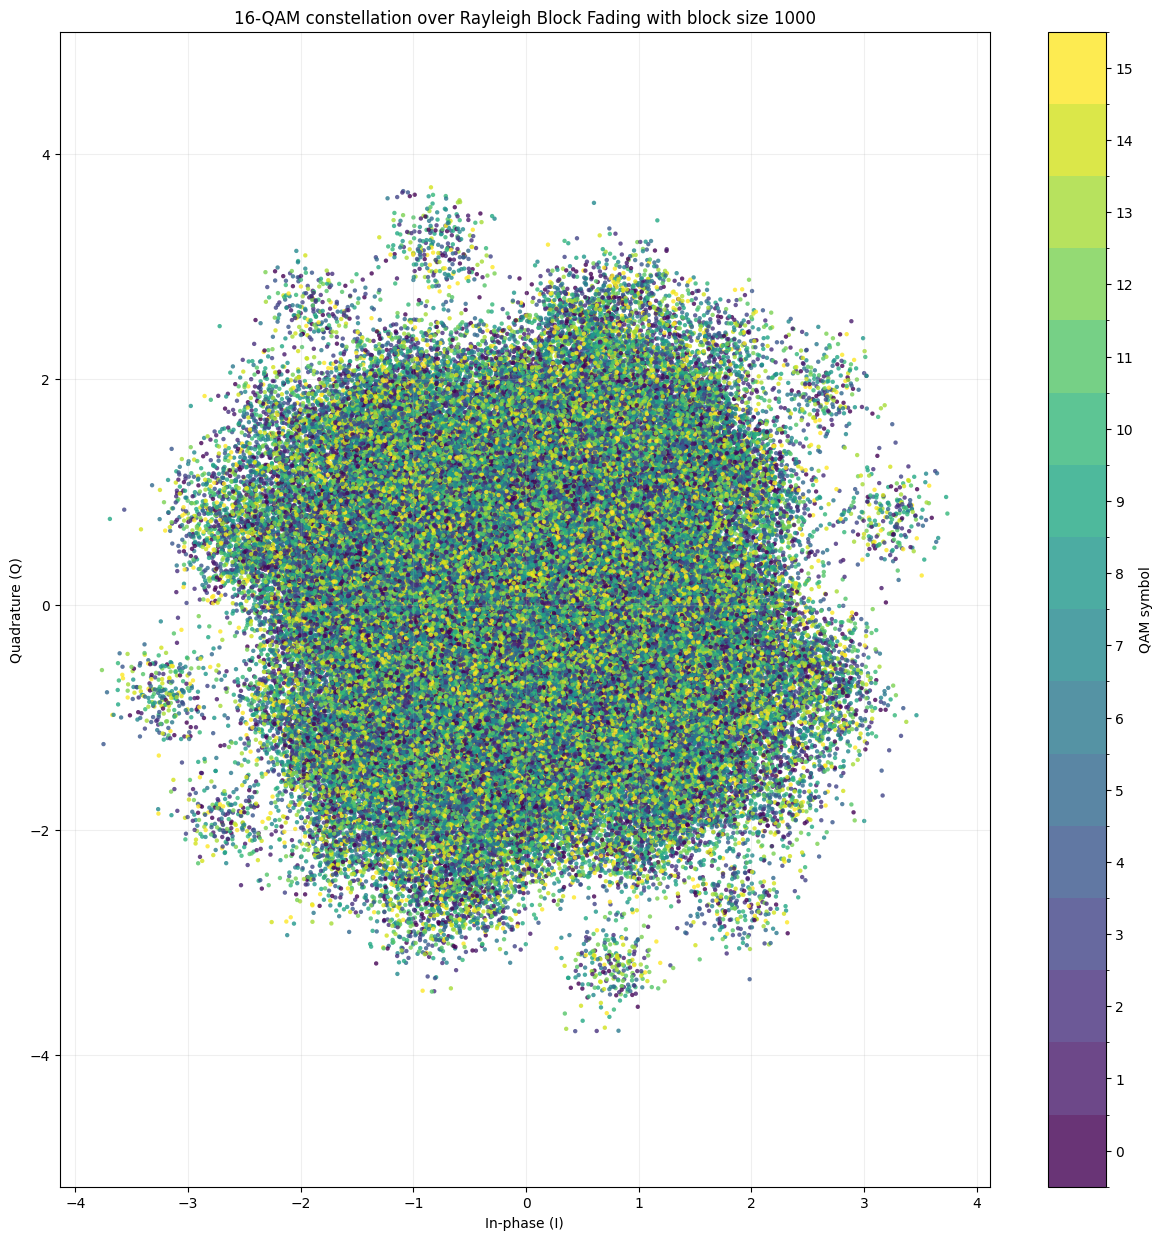

In [14]:
base1 = cm.get_cmap( "viridis",M)
cmap1 = ListedColormap(base1(np.arange(M)))

plt.figure(figsize=(15, 15))
sc = plt.scatter(
    rayleighBlockInPhase, rayleighBlockQuadrature,
    c=label_indices, cmap=cmap1, norm=norm,
    s=10, alpha=0.8, linewidths=0
)

cbar = plt.colorbar(sc, ticks=np.arange(M))
cbar.set_label("QAM symbol")

plt.title(f"{M}-QAM constellation over Rayleigh Block Fading with block size {block_size}")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.axis("equal")
plt.grid(True, alpha=0.2)
plt.show()


C:\Users\Jonas Pedesk\AppData\Local\Temp\ipykernel_7968\127176367.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base1 = cm.get_cmap( "viridis",M)


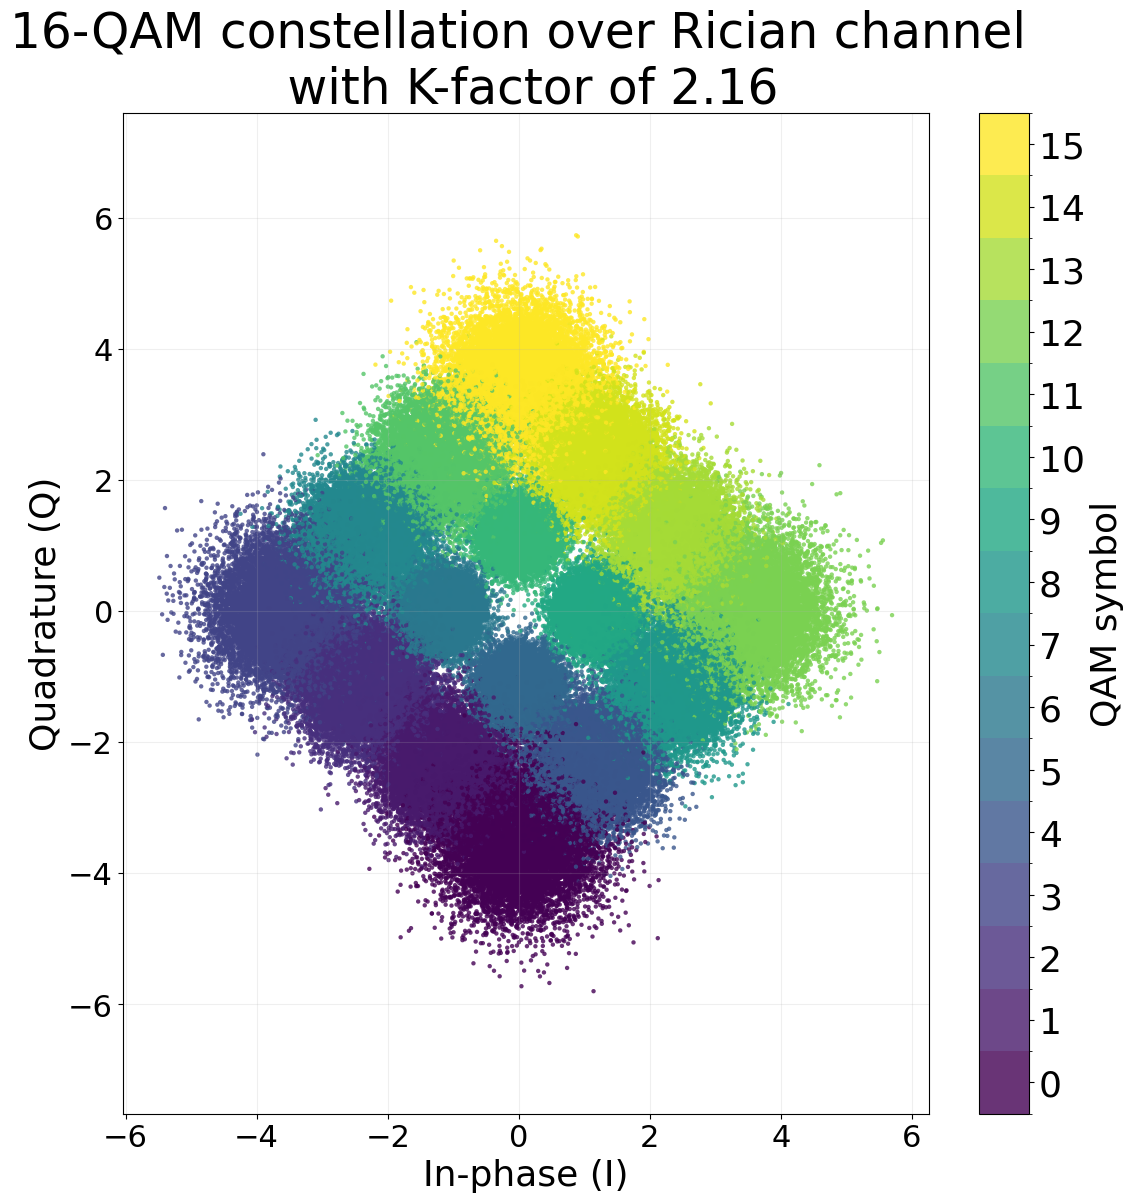

In [15]:
RicianChannel = hChannel + noise
inPhaseRician = RicianChannel.real
quadRatureRician = RicianChannel.imag
base1 = cm.get_cmap( "viridis",M)
cmap1 = ListedColormap(base1(np.arange(M)))

plt.figure(figsize=(13, 13))
sc = plt.scatter(
    inPhaseRician, quadRatureRician,
    c=label_indices, cmap=cmap1, norm=norm,
    s=10, alpha=0.8, linewidths=0
)

cbar = plt.colorbar(sc, ticks=np.arange(M))
cbar.set_label("QAM symbol", fontsize=26)
cbar.ax.tick_params(labelsize=26)

plt.title(f"{M}-QAM constellation over Rician channel \n with K-factor of {K_factor}",fontsize=35)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("In-phase (I)",fontsize=26)
plt.ylabel("Quadrature (Q)",fontsize=26)
plt.axis("equal")
plt.grid(True, alpha=0.2)
plt.show()

C:\Users\Jonas Pedesk\AppData\Local\Temp\ipykernel_7968\3822683464.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base1 = cm.get_cmap( "viridis",M)


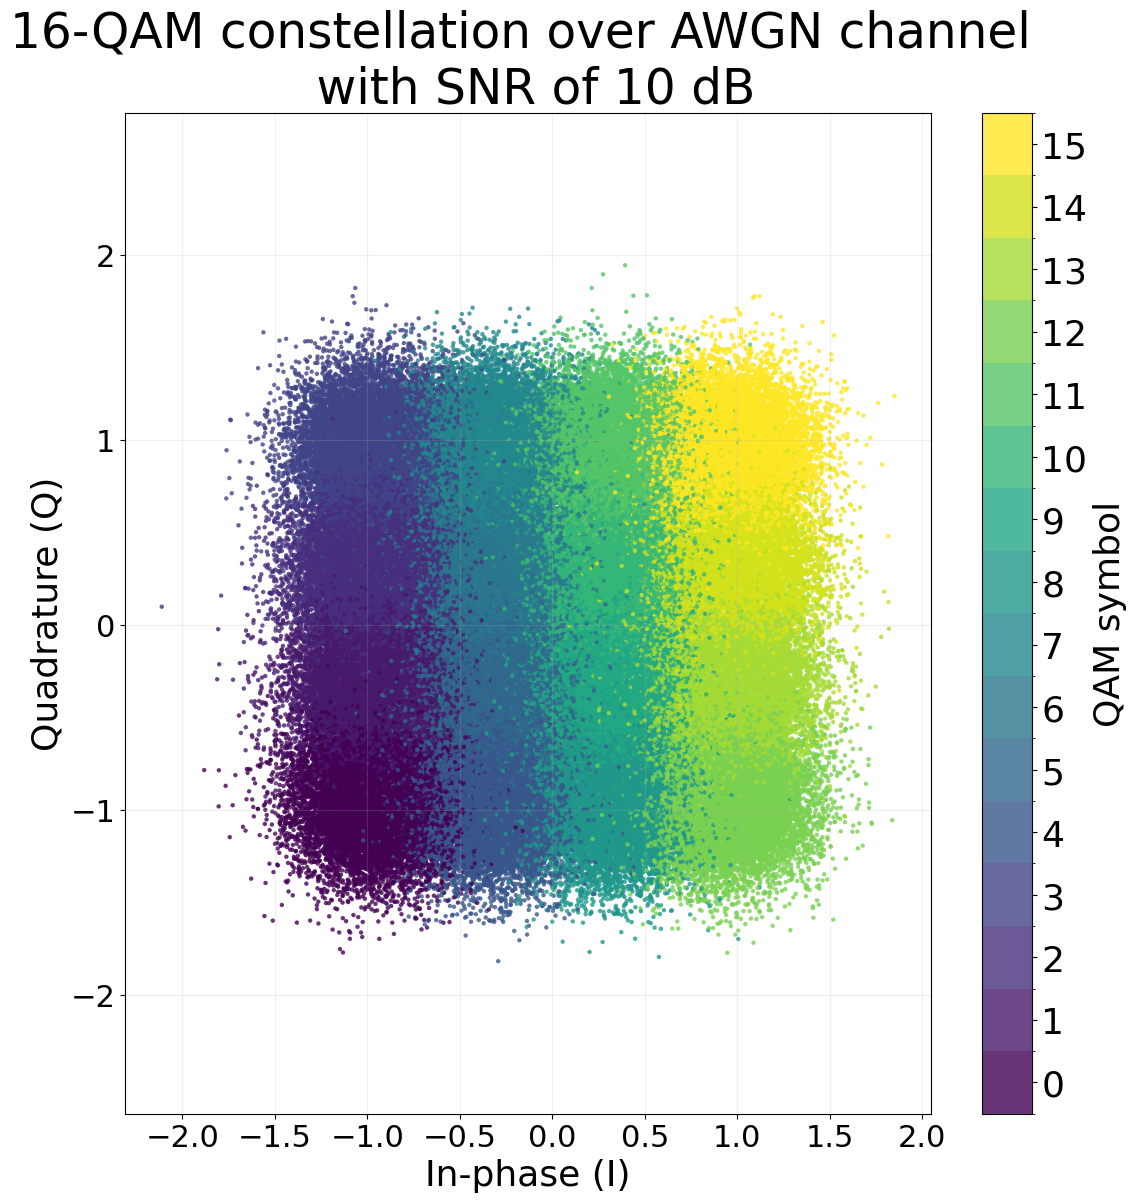

In [16]:
base1 = cm.get_cmap( "viridis",M)
cmap1 = ListedColormap(base1(np.arange(M)))

plt.figure(figsize=(13, 13))
sc = plt.scatter(
    inPhaseAWGN, quadRatureAWGN,
    c=label_indices, cmap=cmap1, norm=norm,
    s=10, alpha=0.8, linewidths=0
)

cbar = plt.colorbar(sc, ticks=np.arange(M))
cbar.set_label("QAM symbol", fontsize=26)
cbar.ax.tick_params(labelsize=26)

plt.title(f"{M}-QAM constellation over AWGN channel \n with SNR of {snr_db} dB", fontsize=35)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("In-phase (I)", fontsize=26)
plt.ylabel("Quadrature (Q)", fontsize=26)
plt.axis("equal")
plt.grid(True, alpha=0.2)
plt.show()

C:\Users\jonas\AppData\Local\Temp\ipykernel_9768\3304892757.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base1 = cm.get_cmap( "viridis",M)


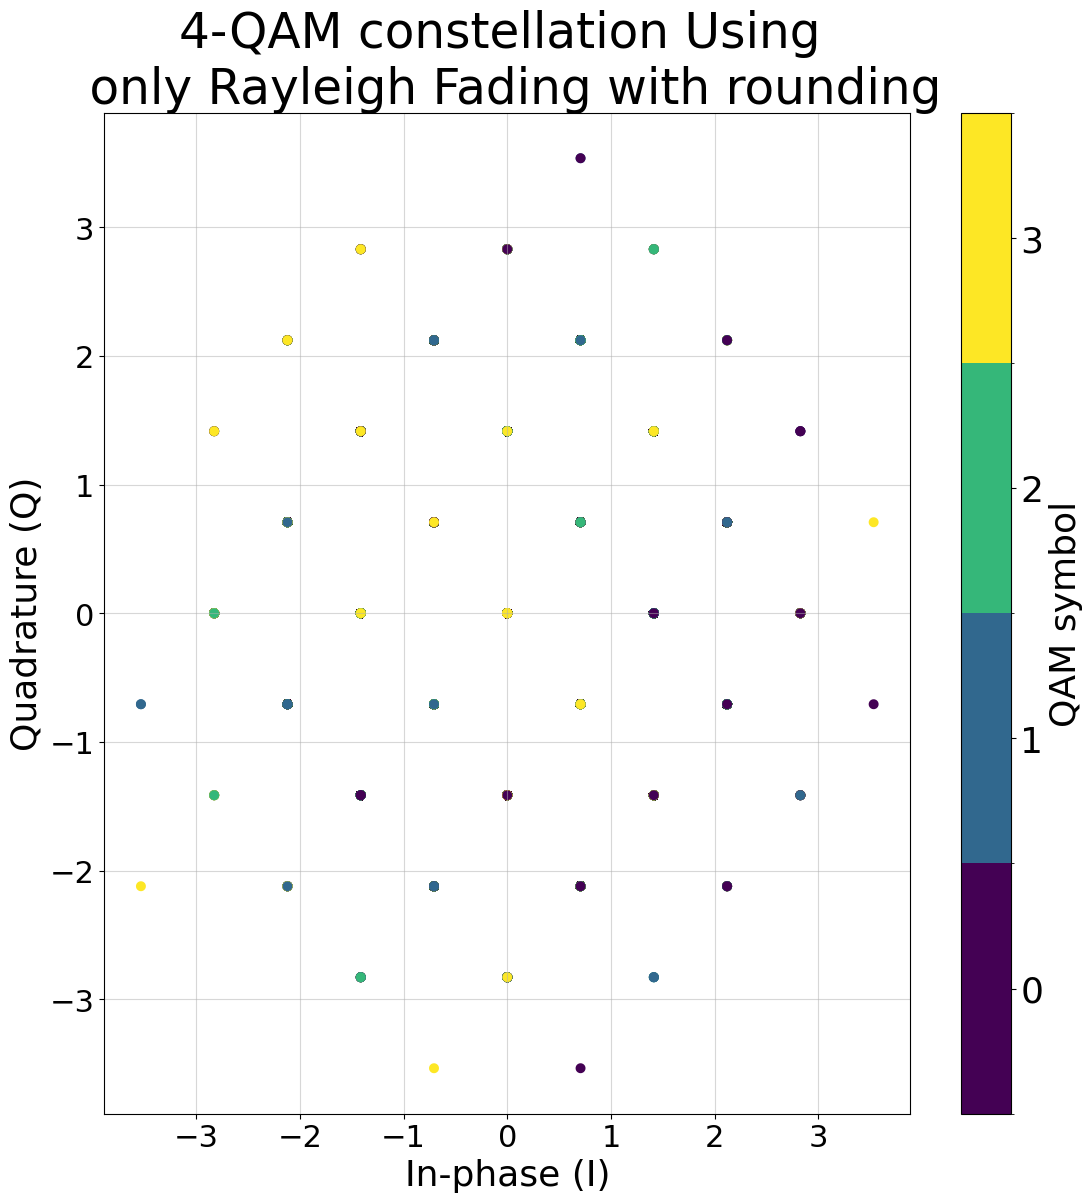

In [41]:
base1 = cm.get_cmap( "viridis",M)
cmap1 = ListedColormap(base1(np.arange(M)))

plt.figure(figsize=(13, 13))
sc = plt.scatter(
    inPhaseRayleighRound, quadRatureRayleighRound,
    c=label_indices, 
    cmap=cmap1, 
    norm=norm,
    s=10, 
    alpha=1.0, 
    linewidths=4
)
cbar = plt.colorbar(sc, ticks=np.arange(M))
cbar.set_label("QAM symbol", fontsize=26)
cbar.ax.tick_params(labelsize=26)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.title(f"{M}-QAM constellation Using \n only Rayleigh Fading with rounding",fontsize=35)
plt.xlabel("In-phase (I)",fontsize=26)
plt.ylabel("Quadrature (Q)",fontsize=26)
plt.grid(True, alpha=0.5)


C:\Users\Jonas Pedesk\AppData\Local\Temp\ipykernel_30116\3636290791.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base1 = cm.get_cmap( "viridis",M)


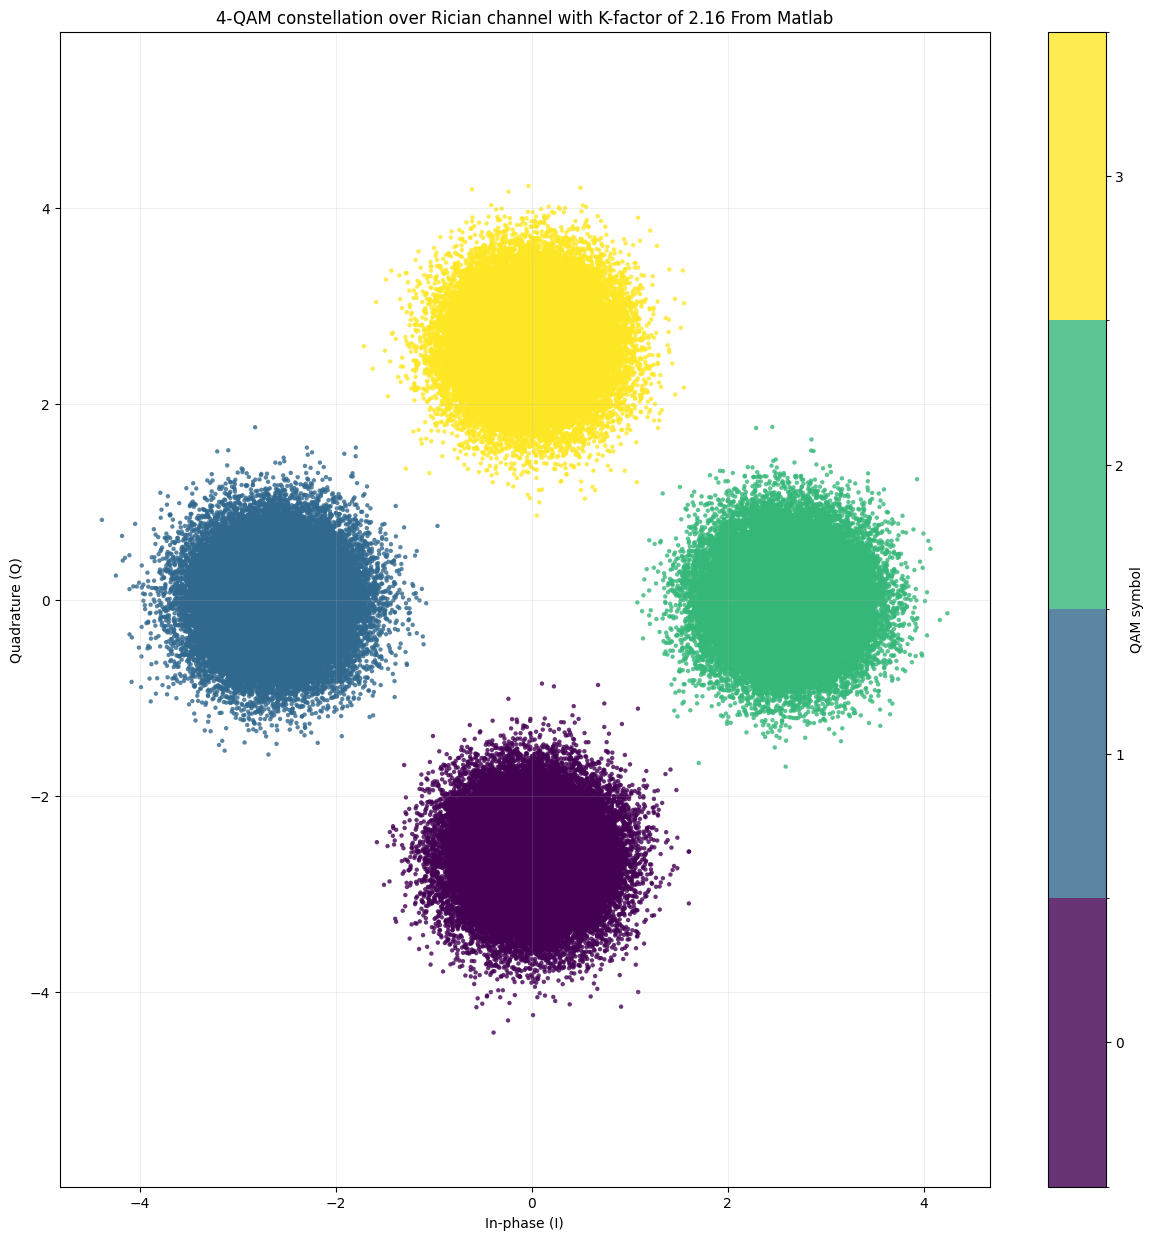

In [14]:
inPhaseRicianMat, quadRatureRicianMat = RicianChannelMat.real,RicianChannelMat.imag

base1 = cm.get_cmap( "viridis",M)
cmap1 = ListedColormap(base1(np.arange(M)))

plt.figure(figsize=(15, 15))
sc = plt.scatter(
    inPhaseRicianMat, quadRatureRicianMat,
    c=label_indices, cmap=cmap1, norm=norm,
    s=10, alpha=0.8, linewidths=0
)

cbar = plt.colorbar(sc, ticks=np.arange(M))
cbar.set_label("QAM symbol")

plt.title(f"{M}-QAM constellation over Rician channel with K-factor of {K_factor} From Matlab")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.axis("equal")
plt.grid(True, alpha=0.2)
plt.show()

In [27]:

# Save noisy samples and labels to CSV
data_to_save = np.column_stack([
    blockChannel.real,          # noisy I
    blockChannel.imag,          # noisy Q
    label_indices,         # class label (0..M-1)
    y_clean.real,          # clean I (target)
    y_clean.imag           # clean Q (target)
])

np.savetxt(
    "4qam_noisy_with_labels_rayleigh_block_fading_1000.csv",
    data_to_save,
    delimiter=",",
    header="noisy_I,noisy_Q,label_index,clean_I,clean_Q",
    comments="",
    fmt=["%.6f","%.6f","%d", "%.6f", "%.6f"]
)

print("Saved: qam_noisy_with_labels.csv")



Saved: qam_noisy_with_labels.csv


In [17]:
# Save noisy samples and labels to CSV
data_to_save = np.column_stack([
    RicianChannel.real,          # noisy I
    RicianChannel.imag,          # noisy Q
    label_indices,         # class label (0..M-1)
    y_clean.real,          # clean I (target)
    y_clean.imag           # clean Q (target)
])

np.savetxt(
    f"{M}qam_noisy_with_labels_rician_fading_k_{K_factor}_snr_{snr_db}.csv",
    data_to_save,
    delimiter=",",
    header="noisy_I,noisy_Q,label_index,clean_I,clean_Q",
    comments="",
    fmt=["%.6f","%.6f","%d", "%.6f", "%.6f"]
)

print(f"Saved: {M}qam_noisy_with_labels_rician_fading_k_{K_factor}.csv")

Saved: 16qam_noisy_with_labels_rician_fading_k_2.16.csv


In [18]:
for i in range(1,4):

    #Parameters
    num_samples = 200000
    X1 = pd.DataFrame()
    X2 = pd.DataFrame()
    snr_db = 10
    M = 16   # M - QAM
    k = int(np.sqrt(M))
    #block_size = 100000  # samples per fading block; adjust as desired
    block_size = int(num_samples*(1/20))
    #assert k * k == M, "M must be a perfect square for square QAM"

    levels = np.arange(-(k - 1), k, 2, dtype=float) # gives array of numbers. 4QAM wilsl be [-1,1]

    #Bewlow: has both i and q loop through the values in "levels." 
    constellation = np.array([i + 1j * q for i in levels for q in levels], dtype=complex)
    constellation /= np.sqrt(np.mean(np.abs(constellation) ** 2)) #normalized to unit average power. RMS


    # Creating "pure" QAM symbols
    label_indices = rng.integers(0, M, size=num_samples) 

    y_clean = constellation[label_indices]
    y_Unique = np.unique(y_clean)
    unique_labels = np.unique(label_indices)

    ## Noise generation for AWGN
    signal_power = np.mean(np.abs(y_clean) ** 2)  # ~= 1 after normalization
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal(num_samples) + 1j * rng.standard_normal(num_samples)
    )
    ### Rayleigh with Block Fading
    fading_strength_block = 1

    num_blocks = int(np.ceil(num_samples / block_size))

    # generate one complex fading coefficient per block
    h_i_blocks = rng.normal(0, 1, num_blocks)
    h_q_blocks = rng.normal(0, 1, num_blocks)
    h_rayleigh_blocks = (h_i_blocks + 1j * h_q_blocks) / np.sqrt(2)
    h_blocks = (1 - fading_strength_block) + fading_strength_block * h_rayleigh_blocks

    # expand to per-sample channel
    h_block = np.repeat(h_blocks, block_size)[:num_samples]

    # received samples under block fading (no noise)
    received_samples_block = h_block * constellation_point_samples
    blockChannel = received_samples_block + noise
    received_inphase_block = received_samples_block.real
    received_quadrature_block = received_samples_block.imag

    #rayleighBlockInPhase = received_inphase_block
    #rayleighBlockQuadrature = received_quadrature_block
    rayleighBlockInPhase = blockChannel.real
    rayleighBlockQuadrature = blockChannel.imag


    # Rician Channel fading implementation
    K_factor = 2.16  # Rician K-factor (ratio of LOS to scattered power)
    h_los = 1  # LOS component (can be complex if desired)
    mean = np.sqrt(K_factor/2*(K_factor+1))
    var = np.sqrt((1/(2*(K_factor+1))))
    h_scatter_i = rng.normal(mean, var, num_samples)
    h_scatter_q = rng.normal(mean, var, num_samples)
    h_scatter = (h_scatter_i + 1j * h_scatter_q)
    hChannel = h_scatter * y_clean
    RicianChannel = hChannel + noise

    #inPhaseRician = hChannel.real
    #quadRatureRician = hChannel.imag
    inPhaseRician = RicianChannel.real
    quadRatureRician = RicianChannel.imag

    # Save noisy samples and labels to CSV
    data_to_save = np.column_stack([
        blockChannel.real,          # noisy I
        blockChannel.imag,          # noisy Q
        label_indices,         # class label (0..M-1)
        y_clean.real,          # clean I (target)
        y_clean.imag           # clean Q (target)
    ])

    np.savetxt(
        f"{M}qam_noisy_with_labels_rayleigh_block_fading_evaluation_dataset{i}.csv",
        data_to_save,
        delimiter=",",
        header="noisy_I,noisy_Q,label_index,clean_I,clean_Q",
        comments="",
        fmt=["%.6f","%.6f","%d", "%.6f", "%.6f"]
    )

    print("Saved: qam_noisy_with_labels.csv")


    # Save noisy samples and labels to CSV
    data_to_save = np.column_stack([
        RicianChannel.real,          # noisy I
        RicianChannel.imag,          # noisy Q
        label_indices,         # class label (0..M-1)
        y_clean.real,          # clean I (target)
        y_clean.imag           # clean Q (target)
    ])

    np.savetxt(
        f"{M}qam_noisy_with_labels_rician_fading_k_{K_factor}_snr_{snr_db}_evaluation_dataset{i}.csv",
        data_to_save,
        delimiter=",",
        header="noisy_I,noisy_Q,label_index,clean_I,clean_Q",
        comments="",
        fmt=["%.6f","%.6f","%d", "%.6f", "%.6f"]
    )

    print("Saved: qam_noisy_with_labels.csv")


Saved: qam_noisy_with_labels.csv
Saved: qam_noisy_with_labels.csv
Saved: qam_noisy_with_labels.csv
Saved: qam_noisy_with_labels.csv
Saved: qam_noisy_with_labels.csv
Saved: qam_noisy_with_labels.csv


In [26]:
ratio = num_samples/block_size
print(ratio)

20.0


In [15]:
"""
from scipy import fft


transmitterFreq = 6.4e9  # 6.4 GHz
wavelength = 3e8 / transmitterFreq  # Speed of light / frequency


lengthCos = np.pi*2*transmitterFreq
genWaveCos = np.cos(np.linspace(0, lengthCos, num_samples))
lengthSin = np.pi*2*transmitterFreq
genWave = -np.sin(np.linspace(0, lengthSin, num_samples))
plt.plot(genWave[:100])
plt.title("Sine wave signal used for in-phase modulation")
plt.xlabel("Sample Index")
plt.show()
plt.plot(genWaveCos[:100])
plt.title("Cosine wave signal used for quadrature-phase modulation")
plt.xlabel("Sample Index")
plt.show()


# Map QAM symbols to I/Q components (from previously generated labels/constellation)
#qam_symbols = constellation[label_indices]
#inPhase = qam_symbols.real
#quadRature = qam_symbols.imag

# Carriers at transmitterFreq: I -> cosine, Q -> sine
sineCarrier = -genWave  # genWave was created as -sin(...), so this is +sin(...)

inPhaseCombined = R[:, 0]
quadRatureCombined = R[:, 1]


# Modulation sequence: s(t) = I*cos(2*pi*transmitterFreq*t) + Q*sin(2*pi*transmitterFreq*t)
inPhaseMod = [0]*num_samples
quadRatureMod = [0]*num_samples
modulatedSignal = [0]*num_samples

for i in range(0,num_samples):
    inPhaseMod[i] = genWaveCos[i] * inPhaseCombined[i]
    quadRatureMod[i] = genWave[i] * quadRatureCombined[i]
    modulatedSignal[i] = inPhaseMod[i] + quadRatureMod[i]



# Quick check (time domain)
plt.figure(figsize=(20, 4))
plt.plot(modulatedSignal[:500])
plt.title("QAM passband modulation (I*cos + Q*sin)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

# Spectrogram
fs = 20e9
f,t,Zxx = stft(modulatedSignal, fs=2e6, nperseg=256)
plt.figure(figsize=(12, 5))
plt.specgram(modulatedSignal, NFFT=256, Fs=fs, noverlap=128, cmap="viridis")
plt.title("Spectrogram of Modulated Signal")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.colorbar(label="Power/Frequency [dB/Hz]")
plt.tight_layout()
plt.show()


#plt.specgram(modulatedSignal, 
#             NFFT=32, 
#             Fs=fs, 
#             noverlap=16, 
#             cmap="viridis")

# Quick and dirty try 
N = 256
S = [0]*num_samples

for i in range(0,modulatedSignal.__len__(),N):
    x = fft.fftshift(modulatedSignal[i:i+N])[N//2:N]
    Pxx = 10*np.log10(np.real(x * np.conj(x)))
    S.append(Pxx)
    
#S = np.array(S)

f = fft.fftshift(fft.fftfreq(N,d=1/fs))[N//2:N]

plt.imshow(S, origin='lower')



plt.figure(figsize=(20, 4))
plt.plot(modulatedSignal[0:1000])
plt.show()
f,t,Zxx = stft(modulatedSignal, fs=20e9, nperseg=256)
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')



f,t,Zxx = stft(genWave, fs=1e6, nperseg=256)
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')

f,t,Zxx = stft(genWaveCos, fs=1e6, nperseg=256)
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')

"""


'\nfrom scipy import fft\n\n\ntransmitterFreq = 6.4e9  # 6.4 GHz\nwavelength = 3e8 / transmitterFreq  # Speed of light / frequency\n\n\nlengthCos = np.pi*2*transmitterFreq\ngenWaveCos = np.cos(np.linspace(0, lengthCos, num_samples))\nlengthSin = np.pi*2*transmitterFreq\ngenWave = -np.sin(np.linspace(0, lengthSin, num_samples))\nplt.plot(genWave[:100])\nplt.title("Sine wave signal used for in-phase modulation")\nplt.xlabel("Sample Index")\nplt.show()\nplt.plot(genWaveCos[:100])\nplt.title("Cosine wave signal used for quadrature-phase modulation")\nplt.xlabel("Sample Index")\nplt.show()\n\n\n# Map QAM symbols to I/Q components (from previously generated labels/constellation)\n#qam_symbols = constellation[label_indices]\n#inPhase = qam_symbols.real\n#quadRature = qam_symbols.imag\n\n# Carriers at transmitterFreq: I -> cosine, Q -> sine\nsineCarrier = -genWave  # genWave was created as -sin(...), so this is +sin(...)\n\ninPhaseCombined = R[:, 0]\nquadRatureCombined = R[:, 1]\n\n\n# Modulat